# Graph Layout

Force-directed graph layout algorithms for automatically positioning nodes in graphs.

Uses the `draw_graph` function from `graph_renderer.py` for visualization.


In [3]:
import matplotlib.pyplot as plt
import numpy as np

from graph_renderer import draw_graph
from graph_layout import update_node_position, update_all_positions_torch_from_dicts


In [21]:
def simulate_network(nodes, edges, positions=None, node_labels=None,
                     show_animation=False, title="Network simulation",
                     max_iterations=10000, min_movement=0.0001, frame_interval=1,
                     node_repulsion=1, link_attraction=0.1, step_size=0.1, boundary_repulsion=0.1):
    """
    Simulate force-directed network layout using priority queue optimization.
    
    Uses update_node_position from graph_layout module for physics calculations.
    Prioritizes updating nodes with the most movement for efficiency.
    
    Args:
        nodes: dict {node: size} - node sizes (radius in plot coordinates)
        edges: dict {(from, to): weight} - edge weights
        positions: dict {node: (x, y)}, optional - initial positions (defaults to random)
        node_labels: dict {node: label_text}, optional (defaults to node names)
        show_animation: bool - whether to show animation during simulation
        title: str - title for animation frames
        max_iterations: int - maximum number of iterations
        min_movement: float - convergence threshold (stop when max movement < this)
        frame_interval: int - how often to update animation
        node_repulsion: float - repulsion force strength
        link_attraction: float - attraction force strength
        step_size: float - step size for position updates
        boundary_repulsion: float - boundary repulsion strength
    
    Returns:
        dict {node: (x, y)} - final positions
    """
    from IPython.display import clear_output
    import heapq
    
    if node_labels is None:
        node_labels = {node: str(node) for node in nodes.keys()}
    
    node_list = list(nodes.keys())
    
    if positions is None:
        positions = {node: (np.random.uniform(-0.5, 0.5), np.random.uniform(-0.5, 0.5)) for node in node_list}
    
    # Priority queue: (-movement, node) - negative because heapq is min-heap
    priority_queue = [(-1.0, node) for node in node_list]
    heapq.heapify(priority_queue)
    reset_interval = 10 * len(node_list)
    iteration = 0
    
    while iteration < max_iterations and priority_queue:
        neg_movement, active_node = heapq.heappop(priority_queue)
        max_movement = -neg_movement
        
        if max_movement < min_movement:
            if show_animation:
                print(f"Converged at iteration {iteration}: max_movement={max_movement:.6f}")
            break
        
        # Store old position to calculate movement
        old_pos = np.array(positions[active_node])
        
        # Update position using the physics function
        new_pos = update_node_position(
            active_node, nodes, positions, edges,
            node_repulsion=node_repulsion,
            link_attraction=link_attraction,
            step_size=step_size,
            boundary_repulsion=boundary_repulsion
        )
        
        if np.linalg.norm(new_pos) > 1.0:
            raise ValueError("Node position is outside the unit circle", new_pos)

        positions[active_node] = new_pos
        
        # Calculate movement magnitude
        movement = np.linalg.norm(np.array(new_pos) - old_pos)
        heapq.heappush(priority_queue, (-movement, active_node))
        
        iteration += 1
        
        # Track actual maximum movement across all nodes in queue
        actual_max_movement = max(-neg_mov for neg_mov, _ in priority_queue) if priority_queue else 0.0
        
        # Reset priority queue periodically to ensure all nodes get updated
        if iteration % reset_interval == 0:
            priority_queue = [(-1.0, node) for node in node_list]
            heapq.heapify(priority_queue)
            actual_max_movement = 1.0
        
        # Animation
        if show_animation and iteration % frame_interval == 0:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(8, 8))
            max_weight = max(edges.values()) if edges else 1.0
            edge_widths_viz = {(u, v): (edges[(u, v)] / max_weight) * 8 for (u, v) in edges.keys()}
            draw_graph(ax, nodes, positions, edge_widths_viz, node_labels)
            plt.title(f"{title} - Update {iteration} (movement={movement:.4f}, max_movement={actual_max_movement:.4f})")
            plt.tight_layout()
            plt.show()
    
    if show_animation:
        print("Animation complete!")
    return positions


### Small Graph Example: Order Processing State Machine

An order processing state machine. The graphs produced in the next cells show the design and statistical analysis of orders in a fictitious e-commerce system.

1. The design of the order processing system.
2. Frequencies of states and transitions, and the layout of a graph that reflects these frequencies. Run this cell and watch the graph positions stabilize to a more intuitive layout!


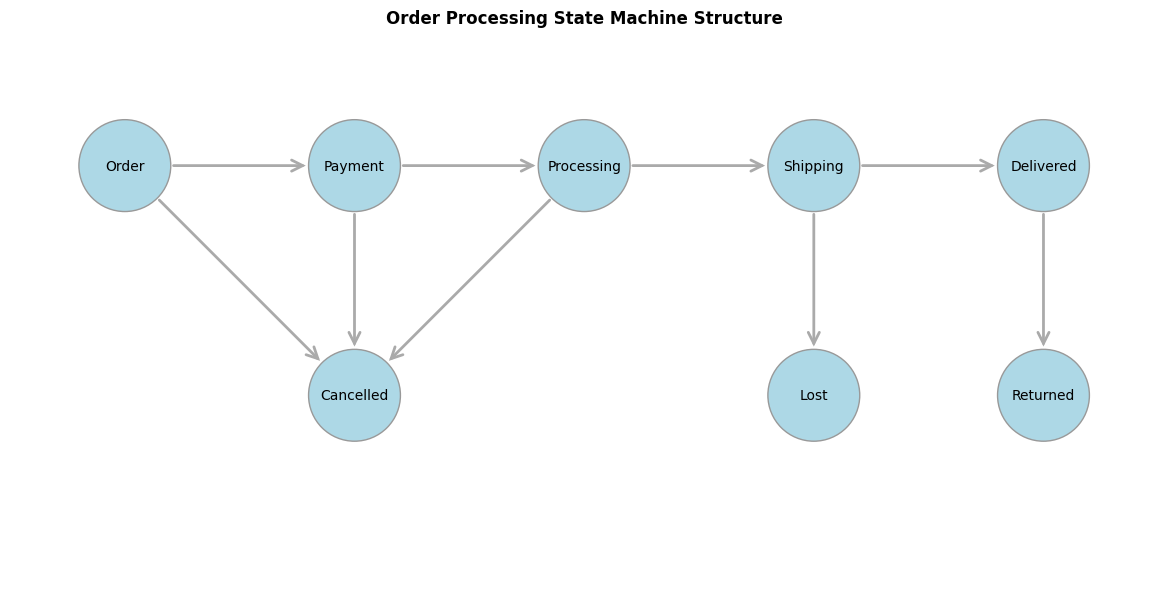

In [29]:
diagram_positions = {
    'Order': (0, 0),
    'Payment': (1, 0),
    'Processing': (2, 0),
    'Shipping': (3, 0),
    'Delivered': (4, 0),
    'Cancelled': (1, -1),
    'Lost': (3, -1),
    'Returned': (4, -1),
}

diagram_nodes = {name: 0.2 for name in diagram_positions}

diagram_edges = {
    # Main chain
    ('Order', 'Payment'): 1.0,
    ('Payment', 'Processing'): 1.0,
    ('Processing', 'Shipping'): 1.0,
    ('Shipping', 'Delivered'): 1.0,
    # Failure paths
    ('Order', 'Cancelled'): 0.5,
    ('Payment', 'Cancelled'): 0.5,
    ('Processing', 'Cancelled'): 0.5,
    ('Shipping', 'Lost'): 0.5,
    ('Delivered', 'Returned'): 0.5,
}

diagram_labels = {node: node for node in diagram_nodes.keys()}

fig, ax = plt.subplots(figsize=(14, 6))
draw_graph(ax, diagram_nodes, diagram_positions, diagram_edges, diagram_labels)
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-1.8, 0.5)
ax.set_title("Order Processing State Machine Structure", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


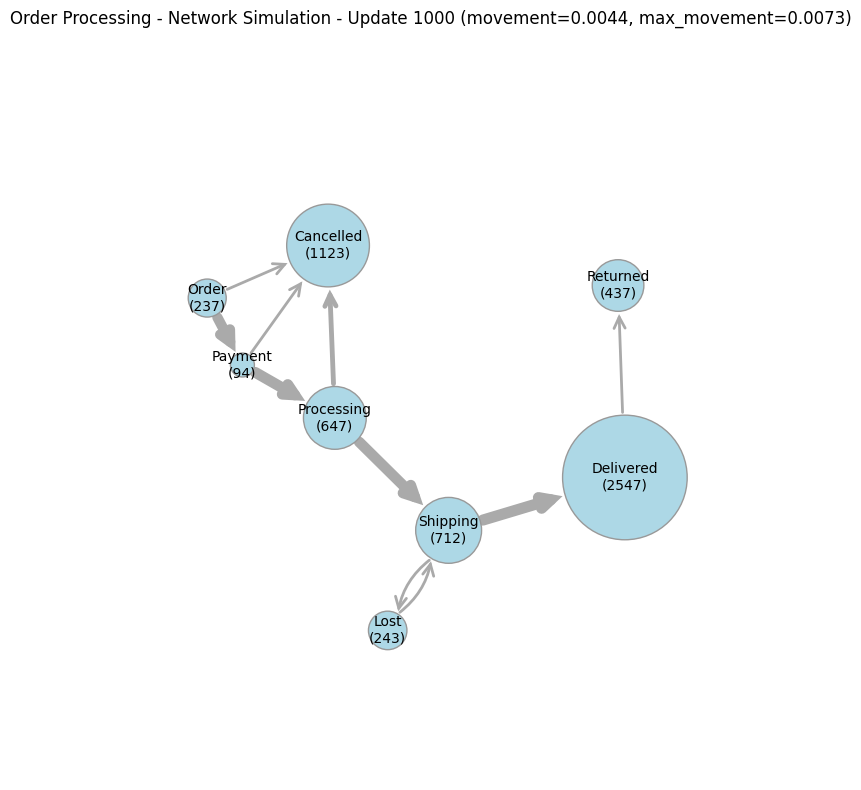

Animation complete!


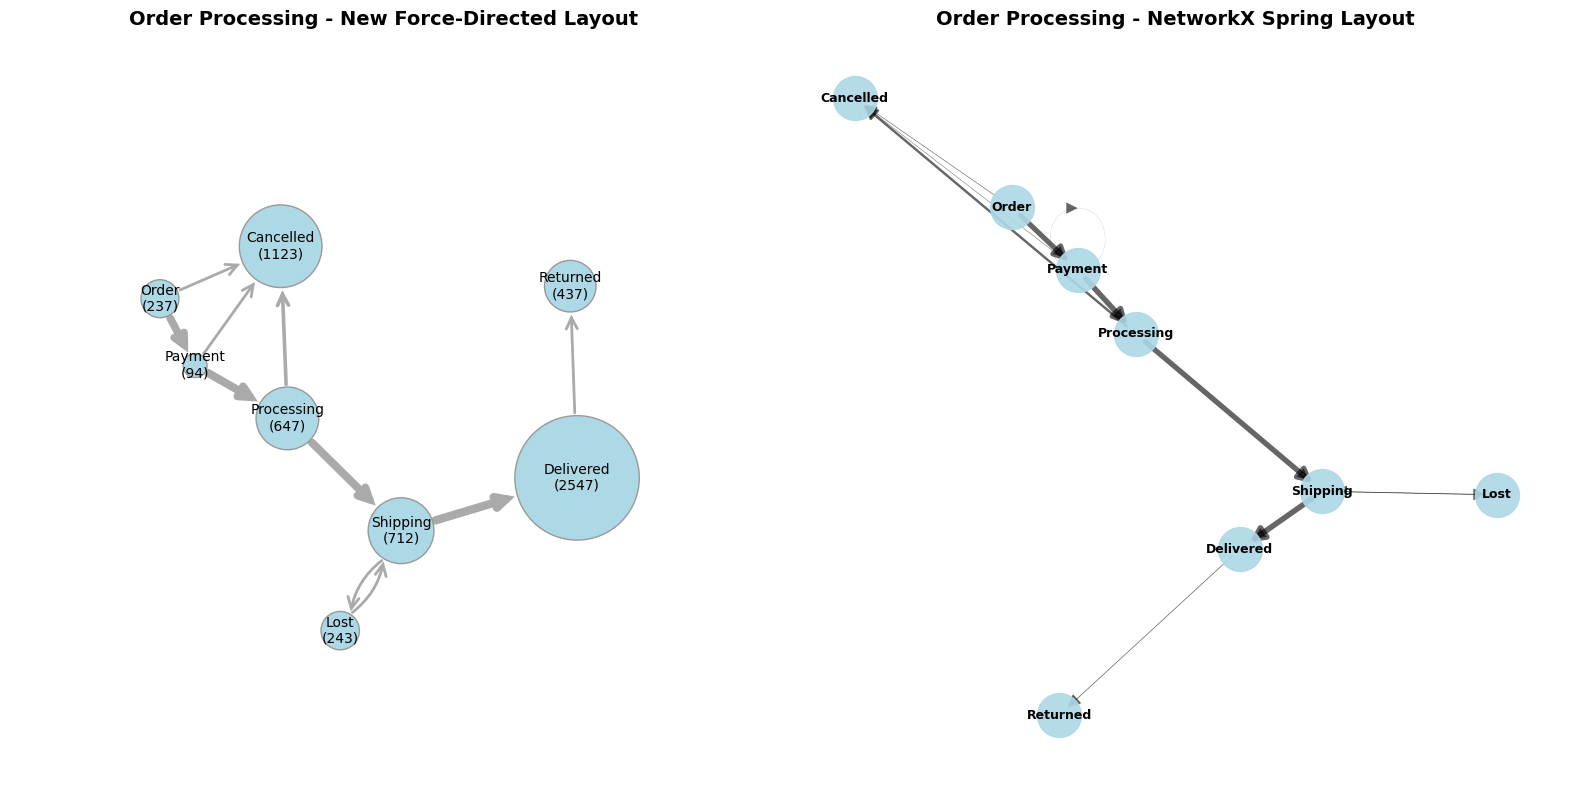

In [60]:
# Order processing state machine
# Nodes represent order states, edges represent transition probabilities
order_edges = {
    # Main successful path (high probability)
    ('Order', 'Payment'): 0.85,
    ('Payment', 'Processing'): 0.90,
    ('Processing', 'Shipping'): 0.88,
    ('Shipping', 'Delivered'): 0.92,
    
    # Failure paths (medium probability)
    ('Order', 'Cancelled'): 0.10,  # Customer cancels before payment
    ('Payment', 'Cancelled'): 0.08,  # Payment fails
    ('Processing', 'Cancelled'): 0.4,  # Order cancelled during processing
    ('Shipping', 'Lost'): 0.06,  # Package lost in transit
    
    # Return path (low probability)
    ('Delivered', 'Returned'): 0.12,  # Customer returns order
    
    # Retry/recovery paths (low probability)
    ('Payment', 'Payment'): 0.02,  # Payment retry
    ('Lost', 'Shipping'): 0.15,  # Package found and re-shipped
}

# Order counts (explicit values reflecting realistic steady-state)
order_counts = {
    'Order': 237,        # Small queue
    'Payment': 94,       # Fast transition, small
    'Processing': 647,   # Bottleneck - takes longer, accumulates orders
    'Shipping': 712,     # Orders in transit
    'Delivered': 2547,   # Terminal state - most orders end here
    'Cancelled': 1123,   # Terminal state - cancelled orders
    'Lost': 243,         # Terminal state - most stay lost (only 15% come back)
    'Returned': 437,     # Terminal state - returned orders
}

# Set node sizes using sqrt scaling (makes smaller nodes relatively bigger)
max_count = max(order_counts.values())
order_nodes = {node: (np.sqrt(count) / np.sqrt(max_count)) * 0.20 for node, count in order_counts.items()}

# Create labels with node name and count in parentheses
order_node_labels = {node: f"{node}\n({count})" for node, count in order_counts.items()}

print(f"Order processing state machine: {len(order_nodes)} nodes, {len(order_edges)} edges")
print(f"Edge weight range: {min(order_edges.values()):.2f} - {max(order_edges.values()):.2f}")
print("Running with animation to show convergence...")

# Run with animation to show convergence
order_positions = simulate_network(
    order_nodes, order_edges,
    node_labels=order_node_labels,
    frame_interval=5,
    node_repulsion=0.5, link_attraction=0.3, step_size=1,
    show_animation=True, title="Order Processing - Network Simulation",
    min_movement=0.0002, max_iterations=1000
)

# Compare with NetworkX spring layout
import networkx as nx

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Our torch layout (final converged positions) - edge width proportional to weight
max_weight = max(order_edges.values())
edge_widths_viz = {(u, v): (order_edges[(u, v)] / max_weight) * 6 for (u, v) in order_edges.keys()}
draw_graph(ax1, order_nodes, order_positions, edge_widths_viz, order_node_labels)
ax1.set_title("Order Processing - New Force-Directed Layout", fontsize=14, fontweight='bold')

# NetworkX spring layout
order_G = nx.DiGraph()
order_G.add_nodes_from(order_nodes.keys())
for (u, v), weight in order_edges.items():
    order_G.add_edge(u, v, weight=weight)

order_nx_pos = nx.spring_layout(order_G, seed=42, iterations=50)
edge_widths_nx = [order_edges.get((u, v), 1) / max_weight * 4 for u, v in order_G.edges()]
nx.draw_networkx_edges(order_G, order_nx_pos, ax=ax2, width=edge_widths_nx, alpha=0.6, arrows=True, arrowsize=20)
nx.draw_networkx_nodes(order_G, order_nx_pos, ax=ax2, node_size=1000, node_color='lightblue', alpha=0.9)
nx.draw_networkx_labels(order_G, order_nx_pos, ax=ax2, font_size=9, font_weight='bold')
ax2.set_title("Order Processing - NetworkX Spring Layout", fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()


### Example: Rick Astley Bigram Model with Force-Directed Layout


In [31]:
# Functions for building n-gram models and generating new phrases
import re
from collections import defaultdict, Counter

START_TOKEN = "<START>"
END_TOKEN = "<END>"

def tokenize_line(line: str):
    """Tokenizes a single line, removes punctuation, and converts to lowercase."""
    clean_line = re.sub(r'[^\w\s]', '', line.lower())
    return clean_line.split()

def build_bigram_model(tokenized_lines):
    """Creates a bigram model, counting occurrences of word pairs, including <START> and <END> tokens."""
    bigram_model = defaultdict(lambda: defaultdict(int))
    
    # Iterate over each tokenized line and create bigrams including <START> and <END> tokens
    for line in tokenized_lines:
        line = [START_TOKEN] + line + [END_TOKEN]
        for i in range(len(line) - 1):
            current_word = line[i]
            next_word = line[i + 1]
            bigram_model[current_word][next_word] += 1
    
    return bigram_model

# Rick Astley - Never Gonna Give You Up (Chorus)
lyrics = """
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
"""

# Tokenize and build bigram model
lines = [line.strip() for line in lyrics.strip().split('\n') if line.strip()]
tokenized_lines = [tokenize_line(line) for line in lines]
bigram_model = build_bigram_model(tokenized_lines)

# Extract nodes and edges from bigram model  
bigram_node_set = set(bigram_model.keys())
bigram_edges = {}
for current_word, next_words in bigram_model.items():
    for next_word, count in next_words.items():
        bigram_node_set.add(next_word)
        bigram_edges[(current_word, next_word)] = count

print(f"Built bigram model with {len(bigram_node_set)} nodes and {len(bigram_edges)} edges")

# Calculate node frequencies
bigram_node_frequencies = Counter()
for line in tokenized_lines:
    bigram_node_frequencies.update(line)
    bigram_node_frequencies[START_TOKEN] += 1
    bigram_node_frequencies[END_TOKEN] += 1

# Node sizes (nodes dict: {node: size})
bigram_sqrt_freqs = {node: np.sqrt(bigram_node_frequencies[node]) for node in bigram_node_set}
bigram_max_sqrt = max(bigram_sqrt_freqs.values())
bigram_nodes = {node: (bigram_sqrt_freqs[node] / bigram_max_sqrt) * 0.15 for node in bigram_node_set}
bigram_node_labels = {node: node for node in bigram_node_set}

Built bigram model with 21 nodes and 29 edges


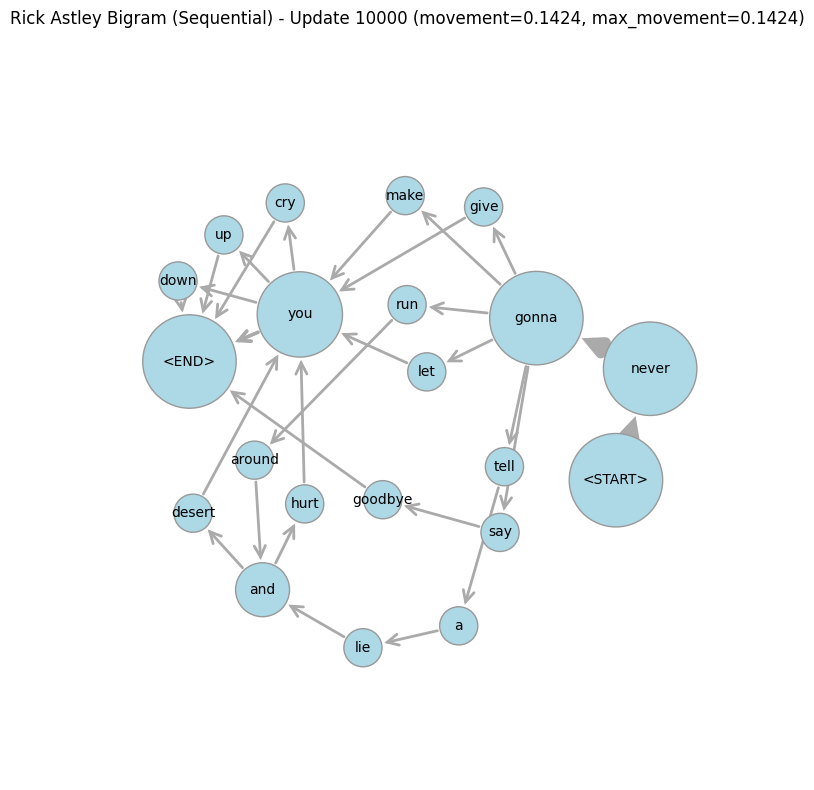

Animation complete!
Completed in 48.88 seconds


In [26]:
# Test on Rick Astley bigram model
print("=" * 60)
print("SEQUENTIAL VERSION (priority queue optimization)")
print("=" * 60)

import time
start = time.time()
seq_positions = simulate_network(
    bigram_nodes, bigram_edges,
    node_labels=bigram_node_labels,
    node_repulsion=0.3,
    link_attraction=0.2,
    step_size=0.5,
    show_animation=True,
    frame_interval=100,
    title="Rick Astley Bigram (Sequential)",
    min_movement=0.00001, max_iterations=10000
)   
seq_time = time.time() - start
print(f"Completed in {seq_time:.2f} seconds")


## Parallel Force-Directed Layout

The sequential implementation above uses a priority queue to optimize convergence by focusing on nodes that are still moving. This is a useful optimization for sequential code, but modern computing is increasingly parallel. GPUs excel at updating thousands of elements simultaneously.

To enable parallelization, we need a **bulk synchronous** algorithm:
- All nodes read current positions (snapshot)
- All nodes compute forces in parallel
- All nodes update positions simultaneously
- Check convergence globally

This mirrors the physics more closely: in reality, all particles experience forces and move at the same time, not one-at-a-time. The matrix-based approach below uses torch operations that automatically leverage multiple CPU cores via multithreaded BLAS (Basic Linear Algebra Subroutine) libraries.

If you also have access to an AMD GPU using ROCm, the torch implementation of these mathematical operations transfers directly.

In [11]:
from graph_layout import update_all_positions_torch_from_dicts


def simulate_network_parallel(nodes, edges, positions=None, node_labels=None, use_torch=False,
                                show_animation=False, title="Network simulation (parallel)",
                                max_iterations=10000, min_movement=0.0001, frame_interval=100,
                                node_repulsion=1, link_attraction=0.1, step_size=0.1, boundary_repulsion=0.1):
    """
    Simulate force-directed network layout using parallel matrix operations.
    All nodes update simultaneously in each iteration.
    
    Uses update_all_positions_parallel for physics calculations.
    
    Args:
        nodes: dict {node: size} - node sizes (radius in plot coordinates)
        edges: dict {(from, to): weight} - edge weights
        positions: dict {node: (x, y)}, optional - initial positions (defaults to random)
        node_labels: dict {node: label_text}, optional (defaults to node names)
        show_animation: bool - whether to show animation during simulation
        title: str - title for animation frames
        max_iterations: int - maximum number of iterations
        min_movement: float - convergence threshold (stop when max movement < this)
        frame_interval: int - how often to update animation
        node_repulsion: float - repulsion force strength
        link_attraction: float - attraction force strength
        step_size: float - step size for position updates
        boundary_repulsion: float - boundary repulsion strength
    
    Returns:
        dict {node: (x, y)} - final positions
    """
    from IPython.display import clear_output
    
    if node_labels is None:
        node_labels = {node: str(node) for node in nodes.keys()}
    
    node_list = list(nodes.keys())
    edge_list = list(edges.keys())
    
    if positions is None:
        positions = {node: (np.random.uniform(-0.5, 0.5), np.random.uniform(-0.5, 0.5)) for node in node_list}
    
    for iteration in range(max_iterations):
        positions, movements = update_all_positions_torch_from_dicts(
            positions, nodes, edges,
            node_repulsion=node_repulsion,
            link_attraction=link_attraction,
            step_size=step_size,
            boundary_repulsion=boundary_repulsion
        )
        
        # === CONVERGENCE CHECK ===
        max_movement = movements.max()
        
        if max_movement < min_movement:
            if show_animation:
                print(f"Converged at iteration {iteration}: max_movement={max_movement:.6f}")
            break
        
        # === ANIMATION ===
        if show_animation and iteration % frame_interval == 0:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(14, 12))
            max_weight = max(edges.values()) if edges else 1.0
            edge_widths_viz = {(u, v): (edges[(u, v)] / max_weight) * 8 for (u, v) in edge_list}
            draw_graph(ax, nodes, positions, edge_widths_viz, node_labels)
            plt.title(f"{title} - Iteration {iteration} (max_movement={max_movement:.4f})")
            plt.tight_layout()
            plt.show()
    
    if show_animation:
        print("Animation complete!")
    return positions


### Comparison: Sequential vs Parallel Implementations


Sequential version (priority queue optimization)
Completed in 6.58 seconds

torch version (bulk synchronous, matrix operations)
Completed in 5.07 seconds

Speedup: 1.30x


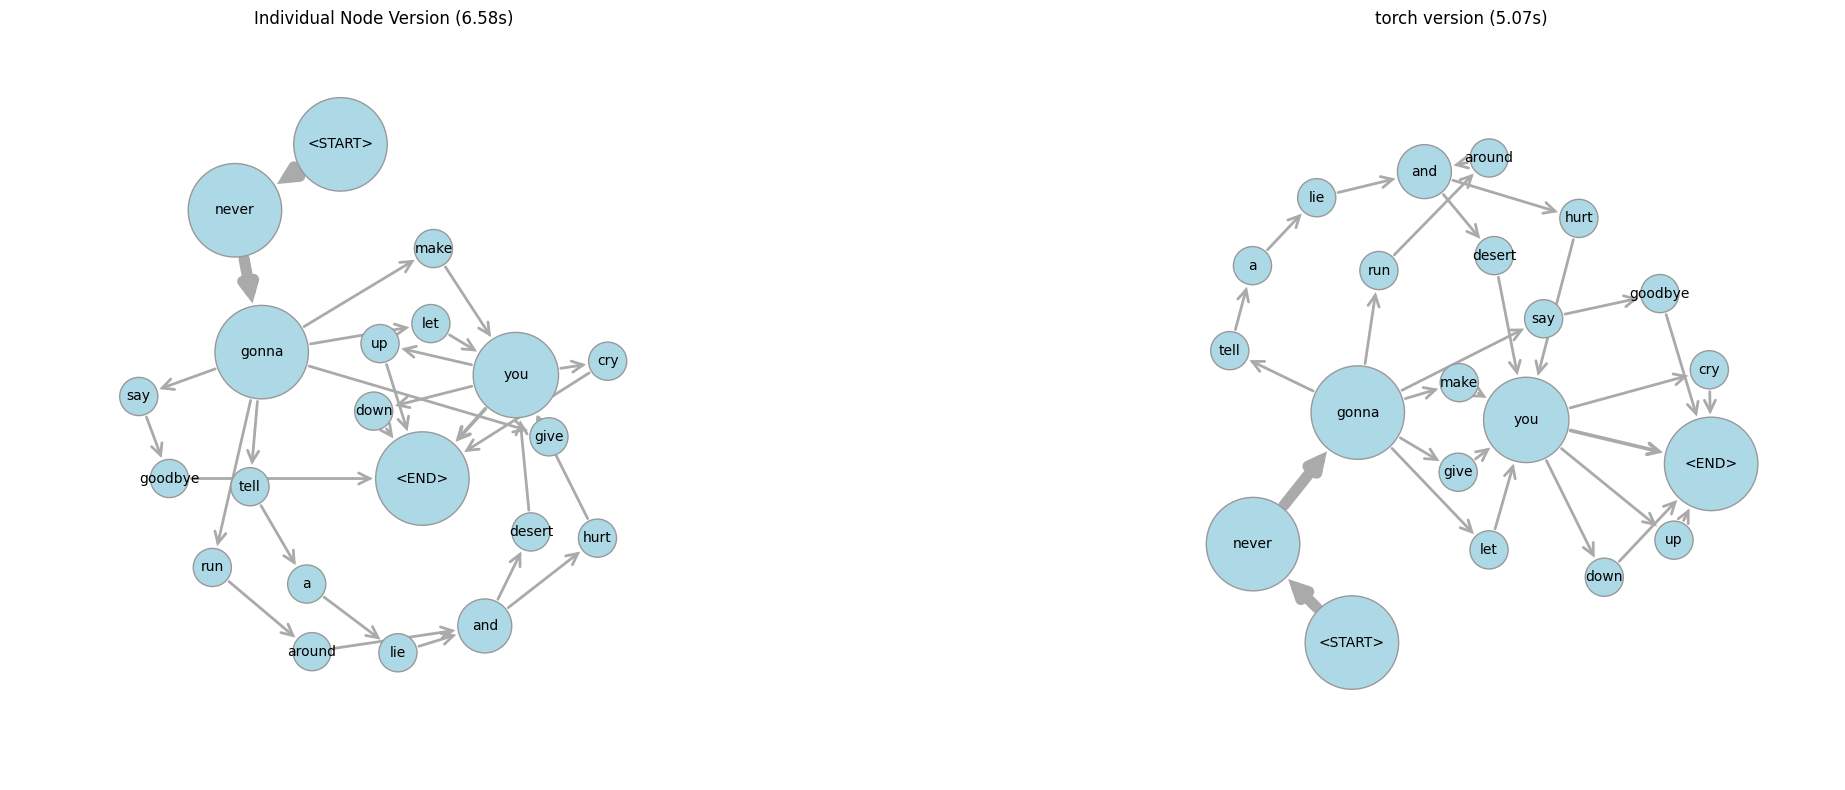

In [14]:
# Test on Rick Astley bigram model
print("=" * 60)
print("Sequential version (priority queue optimization)")
print("=" * 60)

import time
start = time.time()
seq_positions = simulate_network(
    bigram_nodes, bigram_edges,
    node_labels=bigram_node_labels,
    node_repulsion=0.3, link_attraction=0.2, step_size=0.5,
    show_animation=False, title="Rick Astley Bigram (Sequential)",
    min_movement=0.00001, max_iterations=2000
)   
seq_time = time.time() - start
print(f"Completed in {seq_time:.2f} seconds")

print("\n" + "=" * 60)
print("torch version (bulk synchronous, matrix operations)")
print("=" * 60)

start = time.time()
torch_positions = simulate_network_parallel(
    bigram_nodes, bigram_edges,
    node_labels=bigram_node_labels, use_torch=True,
    node_repulsion=0.3, link_attraction=0.2, step_size=0.5,
    show_animation=False, title="Rick Astley Bigram (Parallel)", min_movement=0.00001
)
torch_time = time.time() - start
print(f"Completed in {torch_time:.2f} seconds")
print(f"\nSpeedup: {seq_time/torch_time:.2f}x")

# Visualize results side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))

max_weight = max(bigram_edges.values())
edge_widths_viz = {(u, v): (bigram_edges[(u, v)] / max_weight) * 8 for (u, v) in bigram_edges.keys()}

draw_graph(ax1, bigram_nodes, seq_positions, edge_widths_viz, bigram_node_labels)
ax1.set_title(f"Individual Node Version ({seq_time:.2f}s)")

draw_graph(ax2, bigram_nodes, torch_positions, edge_widths_viz, bigram_node_labels)
ax2.set_title(f"torch version ({torch_time:.2f}s)")

plt.tight_layout()
plt.show()


### Les Misérables Character Network

This extra is a classic graph layout example: character co-occurrence network from Les Misérables.

The cell below compares our layout with the NetworkX Spring layout. Both produce good graphs, given the number of nodes.
Also demonstrates that above a few dozen nodes, even good graph diagrams become quite cumbersome for humans to read effectively. The graph layout problem makes a good mathematical demonstration of GPU acceleration, but visualizations of such large graphs are not always practical for people to use.



Les Misérables graph: 77 nodes, 254 edges

Running torch layout algorithm...
Running NetworkX spring layout...


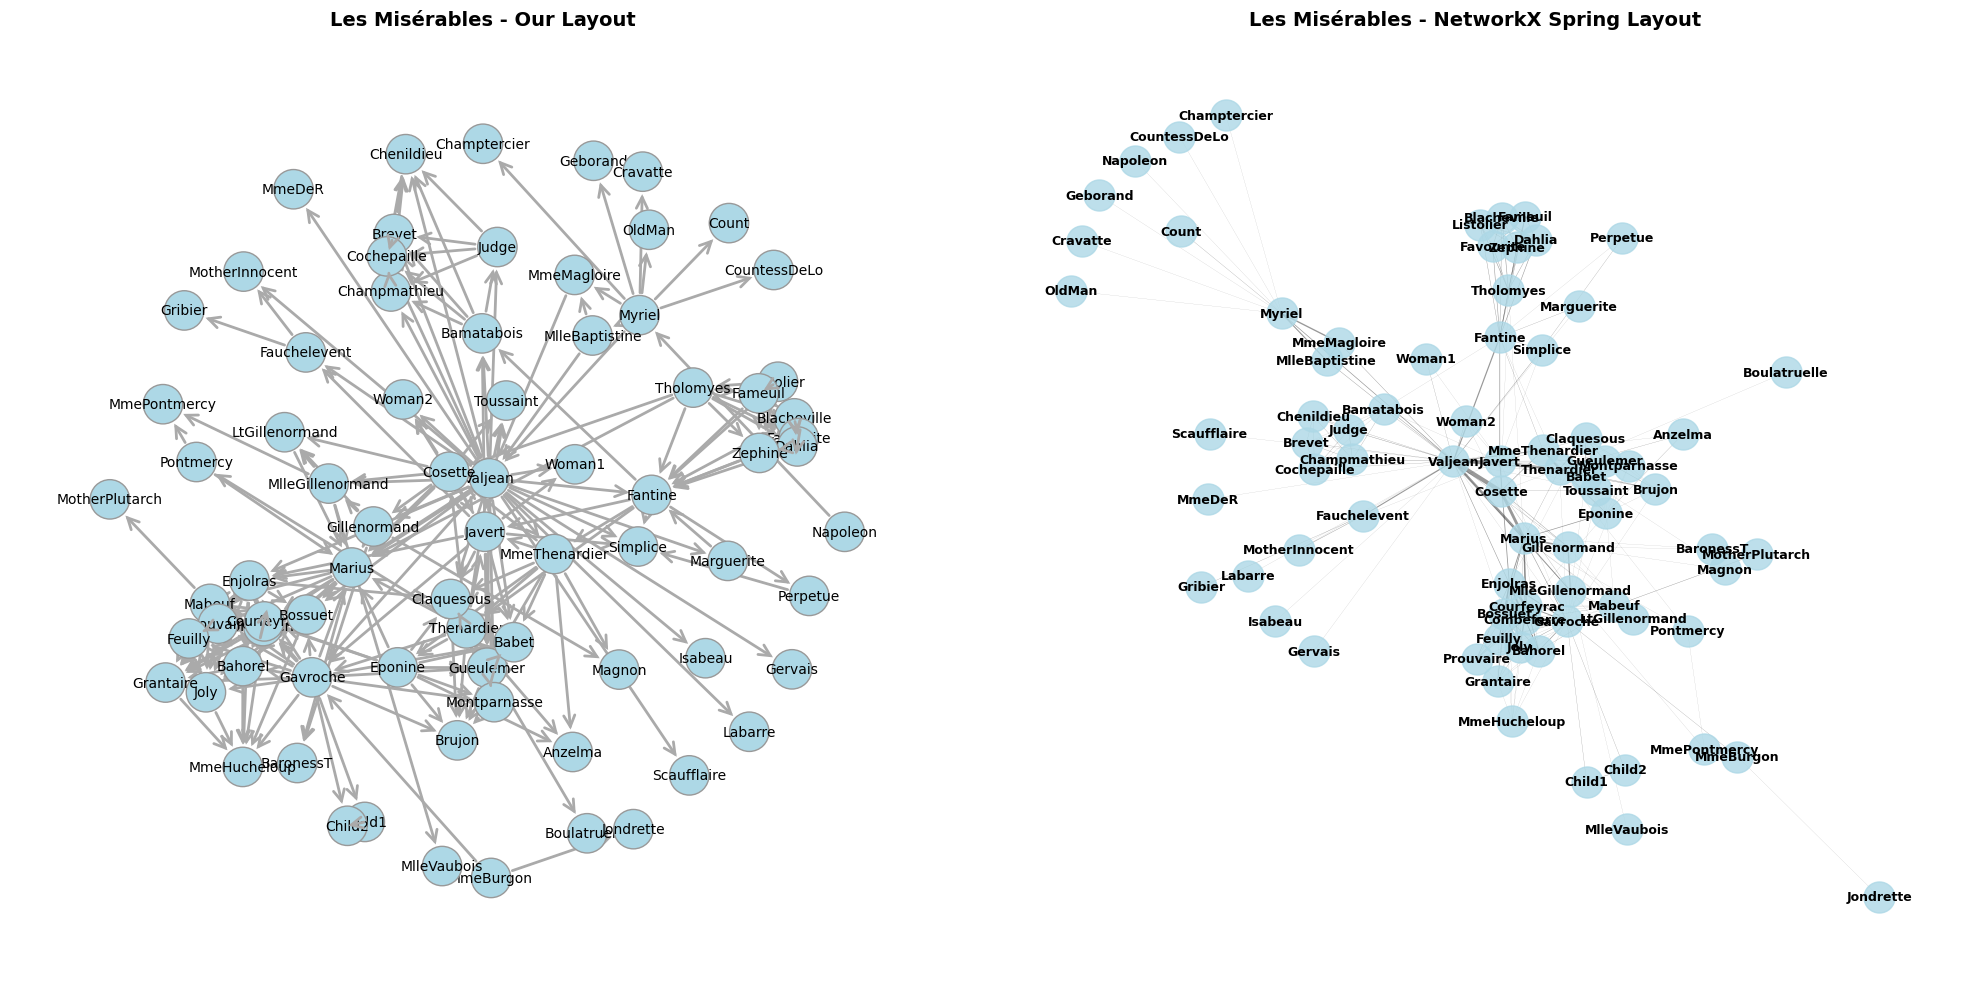

In [33]:
# Load Les Misérables graph from NetworkX
lesmis_G = nx.les_miserables_graph()

# Convert to our format
lesmis_nodes = {node: 0.05 for node in lesmis_G.nodes()}
lesmis_edges = {}
for u, v, data in lesmis_G.edges(data=True):
    weight = data.get('weight', 1.0)
    lesmis_edges[(u, v)] = weight
lesmis_node_labels = {node: node for node in lesmis_G.nodes()}

print(f"Les Misérables graph: {len(lesmis_nodes)} nodes, {len(lesmis_edges)} edges")

# Run our torch layout algorithm
print("\nRunning torch layout algorithm...")
lesmis_torch_positions = simulate_network_parallel(
    lesmis_nodes, lesmis_edges,
    node_labels=lesmis_node_labels,
    use_torch=True,
    node_repulsion=0.7, link_attraction=0.4, step_size=0.2,
    show_animation=False, title="Les Misérables Graph Layout", min_movement=0.00001
)

# Get NetworkX spring layout
print("Running NetworkX spring layout...")
lesmis_nx_pos = nx.spring_layout(lesmis_G, seed=42, iterations=50)

# Visualize side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Our torch layout
max_weight = max(lesmis_edges.values())
edge_widths_viz = {(u, v): (lesmis_edges.get((u, v), 1) / max_weight) * 5 for (u, v) in lesmis_edges.keys()}
draw_graph(ax1, lesmis_nodes, lesmis_torch_positions, edge_widths_viz, lesmis_node_labels)
ax1.set_title("Les Misérables - Our Layout", fontsize=14, fontweight='bold')

# NetworkX spring layout
edge_widths_nx = [lesmis_edges.get((u, v), 1) / max_weight * 3 for u, v in lesmis_G.edges()]
nx.draw_networkx_edges(lesmis_G, lesmis_nx_pos, ax=ax2, width=edge_widths_nx, alpha=0.4)
nx.draw_networkx_nodes(lesmis_G, lesmis_nx_pos, ax=ax2, node_size=500, node_color='lightblue', alpha=0.8)
nx.draw_networkx_labels(lesmis_G, lesmis_nx_pos, ax=ax2, font_size=9, font_weight='bold')
ax2.set_title("Les Misérables - NetworkX Spring Layout", fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()
